In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 📥 Load Dataset
We use CIFAR-10, which contains 60,000 color images of size 32×32×3.

50,000 training images
10,000 test images

In [28]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


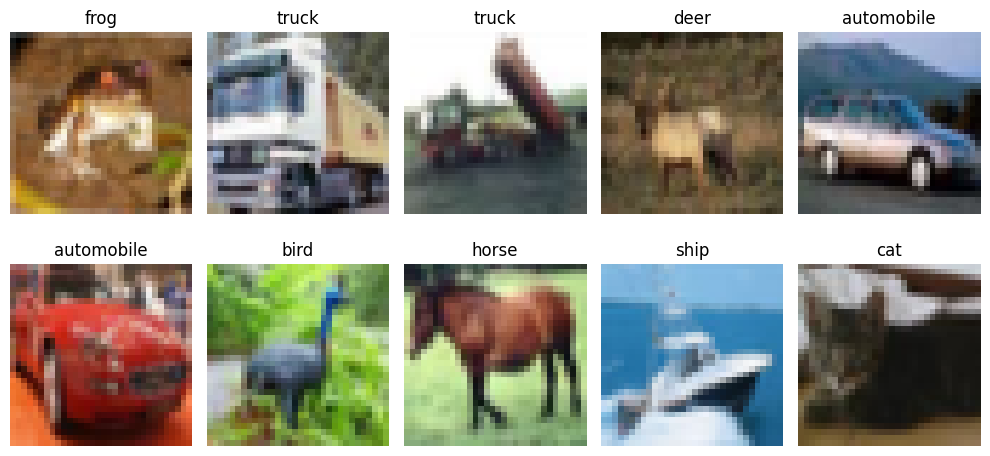

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(len(x_train),3072)
x_test_flat = x_test.reshape(len(x_test),3072)

# 🔹 Part 1: ANN Model


In [5]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128,activation='relu'),

    layers.Dense(10,activation='softmax')
])

In [6]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [8]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.2482 - loss: 2.0336 - val_accuracy: 0.3144 - val_loss: 1.8759
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3006 - loss: 1.9015 - val_accuracy: 0.3378 - val_loss: 1.8421
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3209 - loss: 1.8573 - val_accuracy: 0.3644 - val_loss: 1.7663
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3368 - loss: 1.8172 - val_accuracy: 0.3752 - val_loss: 1.7668
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3475 - loss: 1.7940 - val_accuracy: 0.3716 - val_loss: 1.7410
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3521 - loss: 1.7803 - val_accuracy: 0.4026 - val_loss: 1.7146
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3586 - loss: 1.7587 - val_accuracy: 0.3940 - val_loss: 1.7035
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3647 - loss: 1.7452 - 

# Evaluate

In [9]:
ann_loss, ann_acc = ann_model.evaluate(x_test_flat,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4381 - loss: 1.6159


# 🔹 Part 2: CNN Model


In [10]:
cnn_model=models.Sequential([

layers.Input(shape=(32,32,3)),

layers.Conv2D(32,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D(),

layers.Conv2D(64,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D(),

layers.Conv2D(128,(3,3),activation='relu',padding='same'),
layers.BatchNormalization(),
layers.MaxPooling2D(),

layers.Flatten(),

layers.Dense(256,activation='relu'),
layers.Dropout(0.5),

layers.Dense(10,activation='softmax')

])

In [11]:
cnn_model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [12]:
cnn_history=cnn_model.fit(
x_train,
y_train,
epochs=20,
batch_size=64,
validation_split=0.1,
callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 154s 214ms/step - accuracy: 0.4462 - loss: 1.5684 - val_accuracy: 0.4494 - val_loss: 1.4919
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 208ms/step - accuracy: 0.5915 - loss: 1.1627 - val_accuracy: 0.5972 - val_loss: 1.1595
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 207ms/step - accuracy: 0.6604 - loss: 0.9668 - val_accuracy: 0.6456 - val_loss: 1.0123
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 205ms/step - accuracy: 0.7052 - loss: 0.8477 - val_accuracy: 0.7180 - val_loss: 0.8202
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 206ms/step - accuracy: 0.7344 - loss: 0.7612 - val_accuracy: 0.7354 - val_loss: 0.7537
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 208ms/step - accuracy: 0.7629 - loss: 0.6778 - val_accuracy: 0.6702 - val_loss: 0.9190
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 208ms/step - accuracy: 0.7807 - loss: 0.6206 - val_accuracy: 0.7264 - val_loss: 0.8306
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - accuracy: 0.8008 -

# Evaluate

In [13]:
cnn_loss,cnn_acc=cnn_model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7223 - loss: 0.8041


# Accuracy learning  Curves

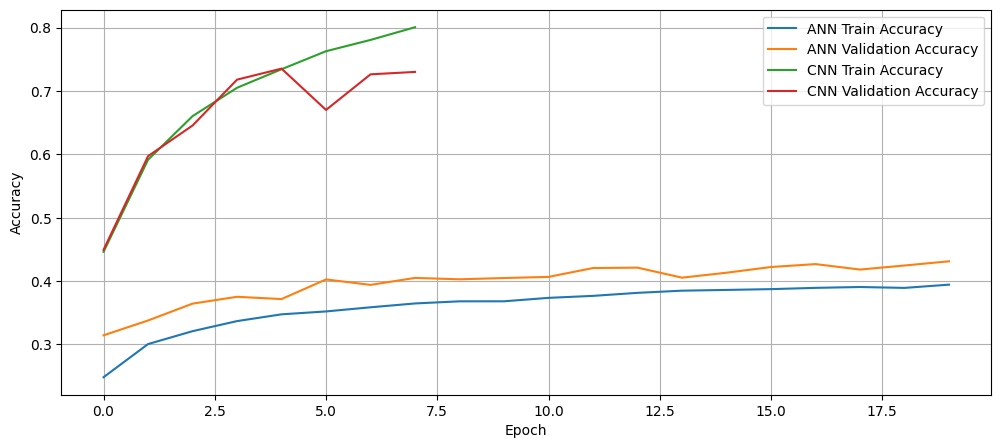

In [30]:
plt.figure(figsize=(12,5))

# ANN
plt.plot(ann_history.history['accuracy'], label='ANN Train Accuracy')
plt.plot(ann_history.history['val_accuracy'], label='ANN Validation Accuracy')

# CNN
plt.plot(cnn_history.history['accuracy'], label='CNN Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#  Loss learning Curves

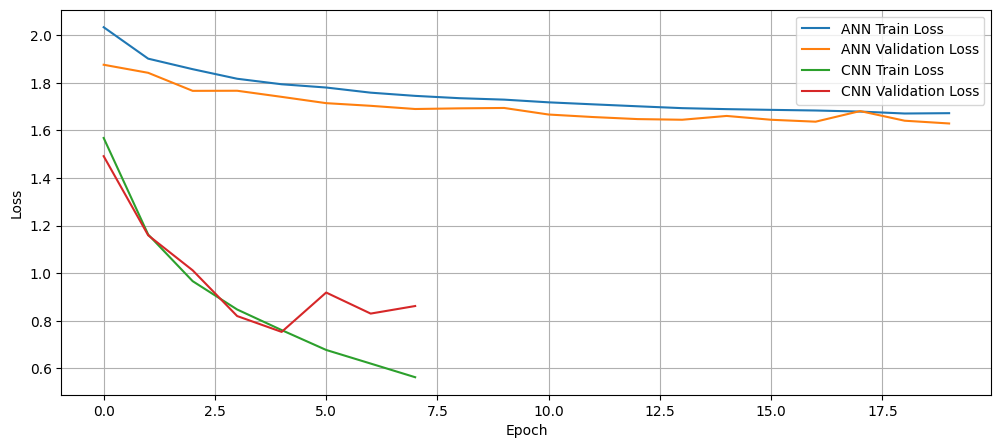

In [31]:
plt.figure(figsize=(12,5))

# ANN
plt.plot(ann_history.history['loss'], label='ANN Train Loss')
plt.plot(ann_history.history['val_loss'], label='ANN Validation Loss')

# CNN
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss')


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Data Augmentation


In [16]:
data_augmentation=tf.keras.Sequential([
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1)
])

# CNN with augmentation

In [17]:
aug_model=models.Sequential([

data_augmentation,

layers.Conv2D(32,3,activation='relu'),
layers.MaxPooling2D(),

layers.Conv2D(64,3,activation='relu'),
layers.MaxPooling2D(),

layers.Conv2D(128,3,activation='relu'),
layers.Flatten(),

layers.Dense(128,activation='relu'),

layers.Dropout(0.4),

layers.Dense(10,activation='softmax')
])

In [21]:
aug_history=aug_model.fit(
x_train,
y_train,
epochs=20,
validation_split=0.1,
callbacks=[early_stop]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.4880 - loss: 1.4335 - val_accuracy: 0.5386 - val_loss: 1.3078
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 141s 61ms/step - accuracy: 0.5242 - loss: 1.3437 - val_accuracy: 0.5788 - val_loss: 1.1834
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 143s 62ms/step - accuracy: 0.5541 - loss: 1.2693 - val_accuracy: 0.6166 - val_loss: 1.0803


In [22]:
aug_loss,aug_acc=aug_model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5347 - loss: 1.3117


# Plot Accuracy

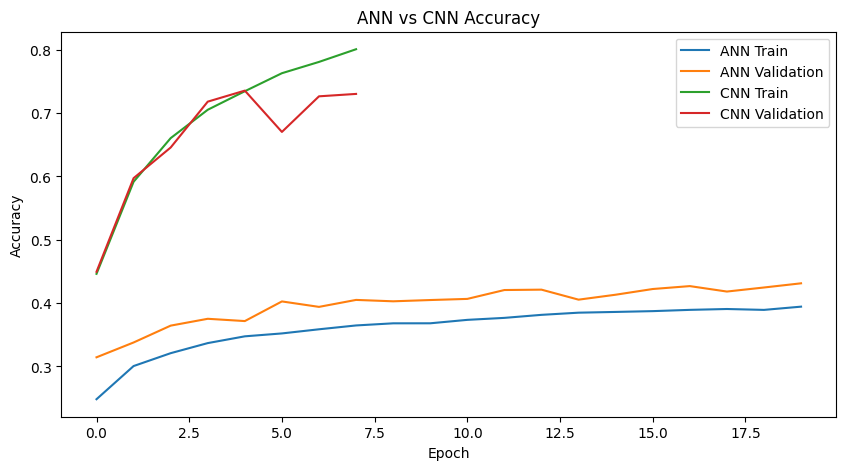

In [23]:
plt.figure(figsize=(10,5))

plt.plot(ann_history.history['accuracy'],label='ANN Train')
plt.plot(ann_history.history['val_accuracy'],label='ANN Validation')

plt.plot(cnn_history.history['accuracy'],label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'],label='CNN Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Accuracy")

plt.legend()
plt.show()

# PLOT LOSS

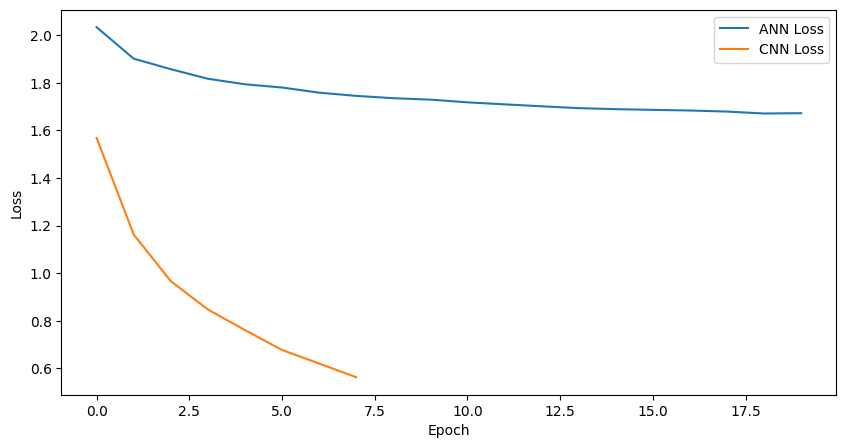

In [24]:
plt.figure(figsize=(10,5))

plt.plot(ann_history.history['loss'],label='ANN Loss')
plt.plot(cnn_history.history['loss'],label='CNN Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step


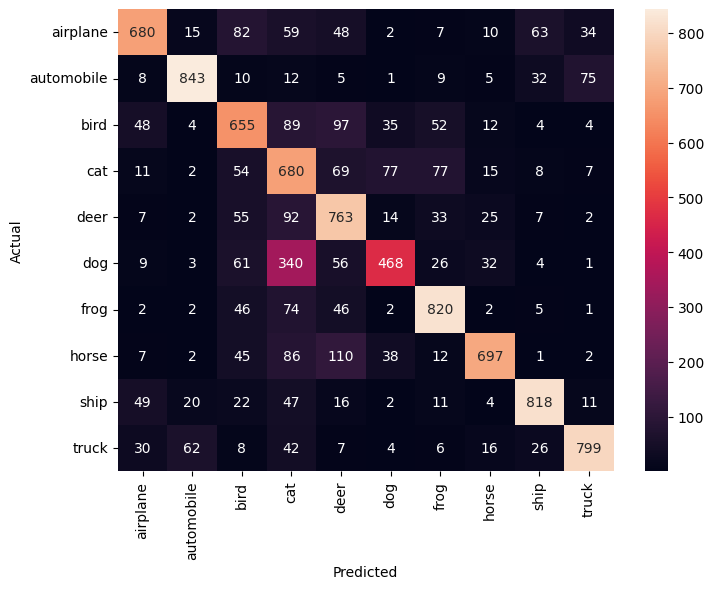

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred=cnn_model.predict(x_test)
pred=np.argmax(pred,axis=1)

cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
annot=True,
fmt='d',
xticklabels=class_names,
yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

In [26]:
from sklearn.metrics import classification_report

print(classification_report(
y_test,
pred,
target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.80      0.68      0.73      1000
  automobile       0.88      0.84      0.86      1000
        bird       0.63      0.66      0.64      1000
         cat       0.45      0.68      0.54      1000
        deer       0.63      0.76      0.69      1000
         dog       0.73      0.47      0.57      1000
        frog       0.78      0.82      0.80      1000
       horse       0.85      0.70      0.77      1000
        ship       0.85      0.82      0.83      1000
       truck       0.85      0.80      0.83      1000

    accuracy                           0.72     10000
   macro avg       0.74      0.72      0.73     10000
weighted avg       0.74      0.72      0.73     10000



# 📊 Final Comparison Table

In [27]:
comparison=pd.DataFrame({

"Model":[
"ANN",
"CNN",
"CNN + Data Augmentation"
],

"Accuracy":[
ann_acc,
cnn_acc,
aug_acc
],

"Loss":[
ann_loss,
cnn_loss,
aug_loss
]

})

comparison

,Model,Accuracy,Loss
0,ANN,0.4381,1.615907
1,CNN,0.7223,0.804096
2,CNN + Data Augmentation,0.5347,1.311683


# Analysis



ANN
Images are flattened into vectors.
Spatial information is lost.
Training is faster.
Lower accuracy.
More prone to overfitting.
CNN
Learns edges, corners and textures.
Preserves spatial relationships.
Higher classification accuracy.
Better feature extraction.
Better generalization.
CNN + Data Augmentation
Random transformations create diverse training samples.
Reduces overfitting.
Improves robustness.
Slightly longer training time.
Highest validation accuracy.

# Final Conclusion
This project compared ANN and CNN architectures on the CIFAR-10 dataset. ANN achieved reasonable performance but struggled because flattening images removes spatial information. CNN significantly outperformed ANN by learning hierarchical image features through convolutional layers. Applying Batch Normalization, Dropout, Early Stopping, and Data Augmentation further improved the CNN's generalization and reduced overfitting. The experimental results demonstrate that CNNs are the preferred architecture for image classification tasks and form the foundation of modern computer vision systems.